## Trabajo Práctico
### Modelo de clasificación
#### Aprendizaje Automático I

Estudiantes:
- Ruiz, Irma Carolina
- Quispe, Rocio

**Carga de librerías iniciales**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

**Carga de datos**

In [3]:
data = pd.read_csv('weatherAUS.csv')

### Análisis Exploratorio de Datos

In [4]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

**Variables Generales**
- Date: Fecha de la observación.
- Location: La ubicación o ciudad en Australia.

**Variables de Temperatura, en °C**
- MinTemp: Temperatura mínima del día.
- MaxTemp: Temperatura máxima del día.
- Temp9am: Temperatura registrada a las 9 de la mañana.
- Temp3pm: Temperatura registrada a las 3 de la tarde.

**Variables de Precipitación y Humedad**
- Rainfall: La cantidad de lluvia registrada ese día, en mm.
- Evaporation: Evaporación de agua de "Clase A" en las 24 horas hasta las 9 am, en milímetros (mm).
- Sunshine: El número de horas de sol brillante durante el día.
- Humidity9am: La humedad relativa a las 9 de la mañana, como un porcentaje.
- Humidity3pm: La humedad relativa a las 3 de la tarde, como un porcentaje.
- RainToday: Indica si hubo precipitación (más de 1 mm) en ese día, o no.

**Variables de Viento**
- WindGustDir: La dirección de la ráfaga de viento más fuerte del día (ej. N, S, SW).
- WindGustSpeed: La velocidad de la ráfaga de viento más fuerte del día, en km/h.
- WindDir9am: La dirección del viento a las 9 de la mañana.
- WindDir3pm: La dirección del viento a las 3 de la tarde.
- WindSpeed9am: La velocidad promedio del viento, a las 9 de la mañana, en km/h.
- WindSpeed3pm: La velocidad promedio del viento a las 3 de la tarde, en km/h.

**Variables Atmosféricas**
- Pressure9am: La presión atmosférica a nivel del mar a las 9 de la mañana, medida en hectopascales (hPa).
- Pressure3pm: La presión atmosférica a las 3 de la tarde, en hPa.
- Cloud9am: La fracción del cielo cubierta por nubes a las 9 de la mañana. Se mide en "oktas", una escala de 0 (cielo completamente despejado) a 8 (cielo completamente cubierto).
- Cloud3pm: La fracción del cielo cubierta por nubes a las 3 de la tarde.

**Variable Objetivo**

*RainTomorrow*: Variable categórica ('Yes'/'No') que responde a la pregunta: "¿Llovió al día siguiente?".

Para agilizar la limpieza, se verifica si hay registros con solo valores nulos.

In [6]:
data.isna().all(axis=1).any()

False

No hay registros solo con datos nulos. Se verifica cuáles tienen nulos y qué porcentaje representa del total.

In [7]:
porc_nulos = data.isnull().sum()/len(data)*100
col_nulos = porc_nulos[porc_nulos>0].sort_values(ascending=False)

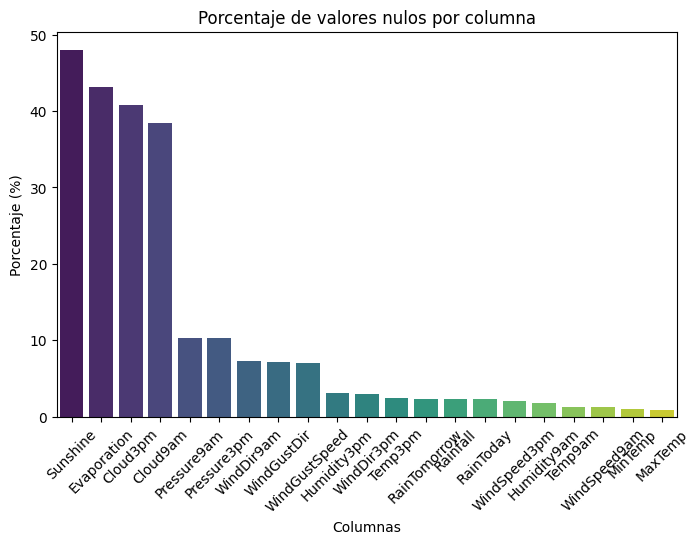

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x=col_nulos.index, y=col_nulos.values, palette='viridis')

plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.show()

Distribución de datos numéricos en histogramas y outliers.

In [9]:
data_num = data[['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 
                 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']]

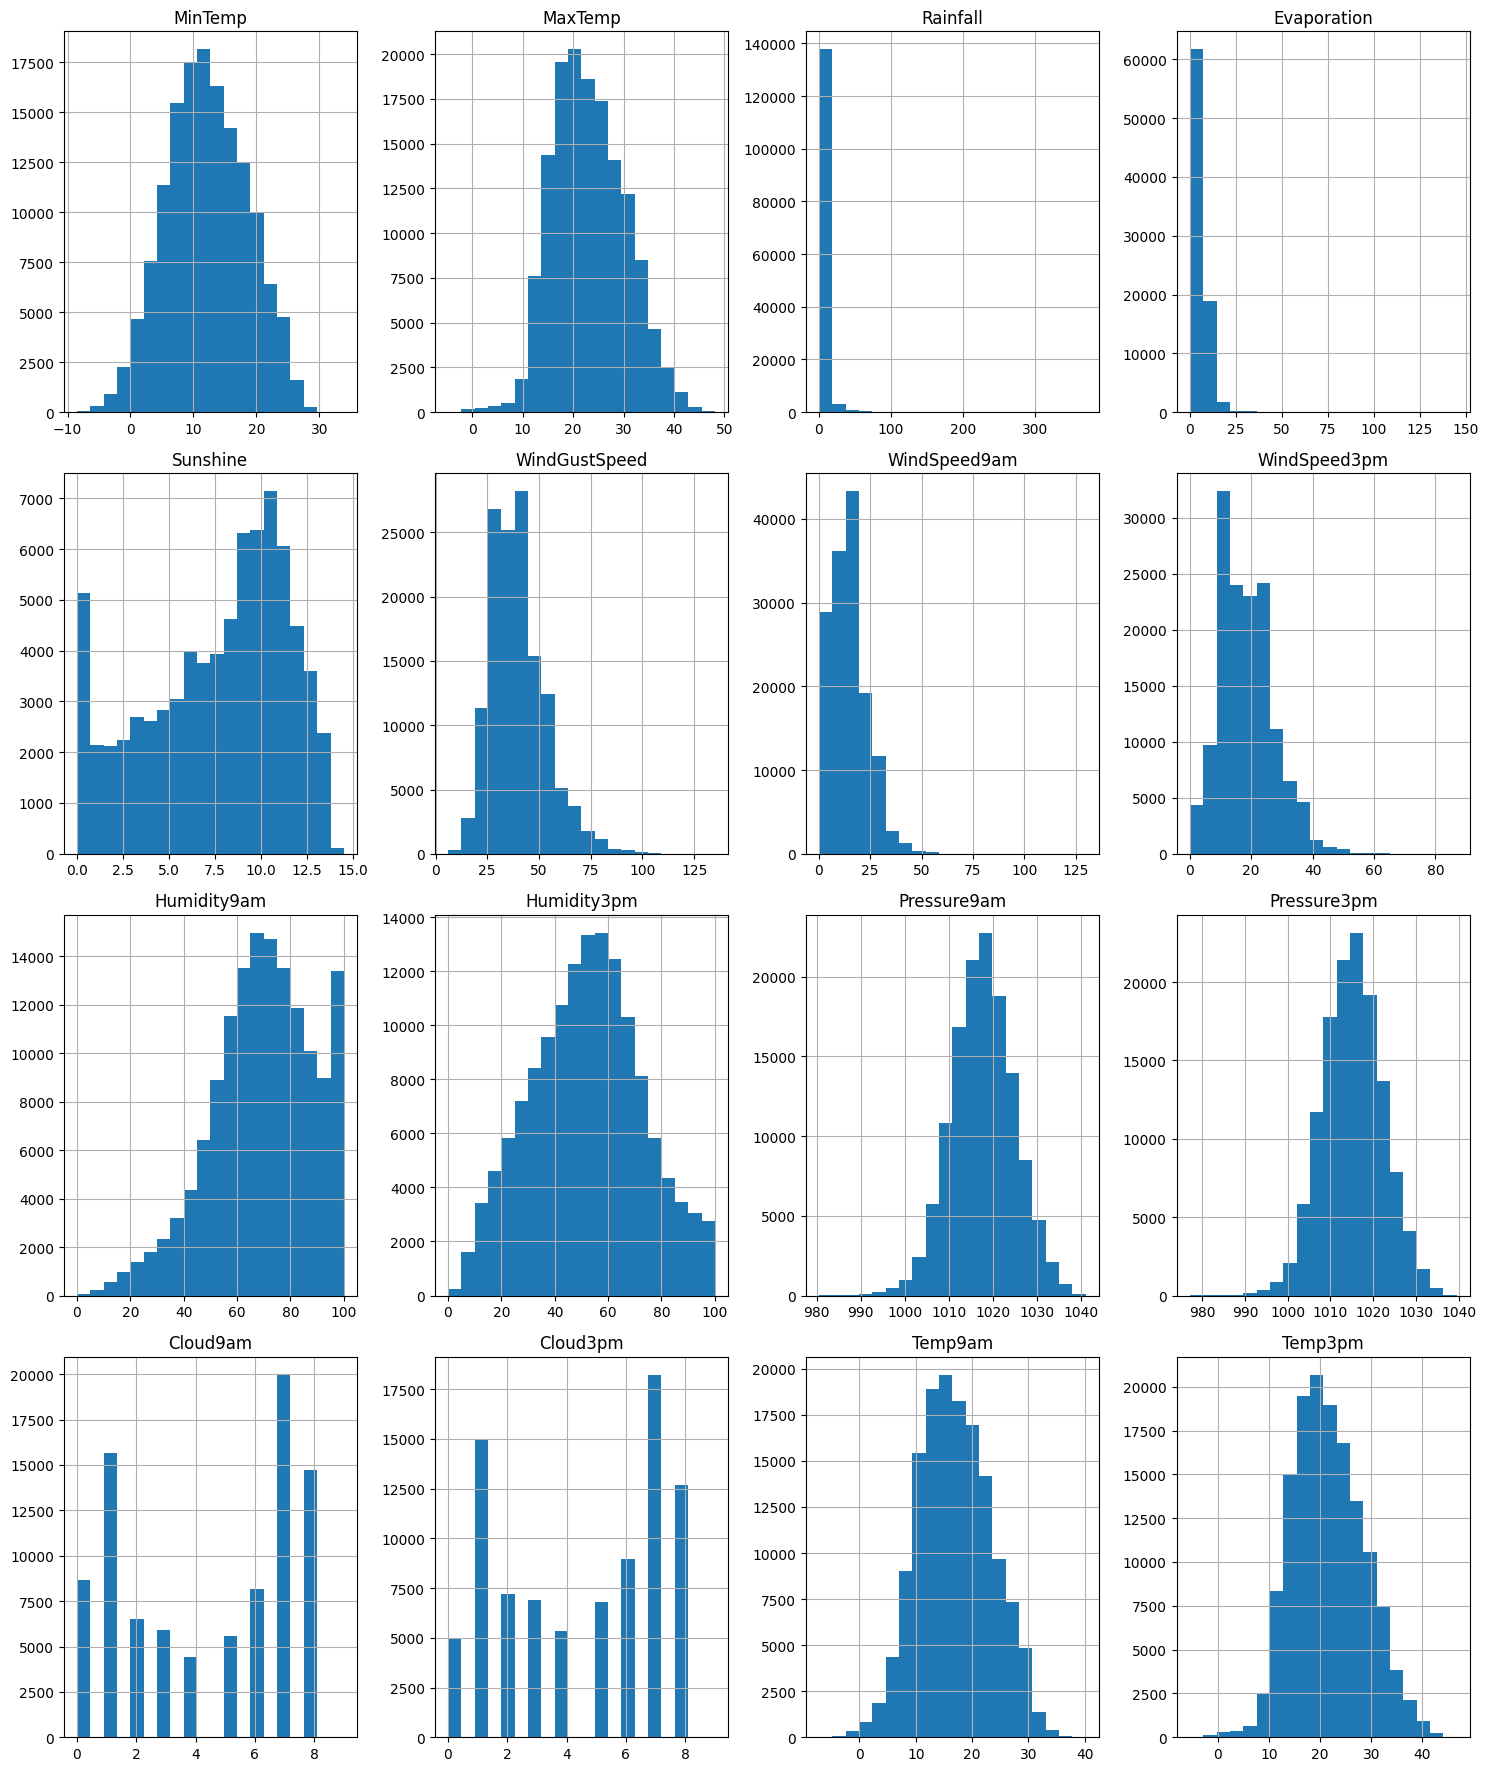

In [10]:
data_num.hist(figsize=(15, 22), bins=20, layout=(5, 4))
plt.tight_layout()
plt.show()

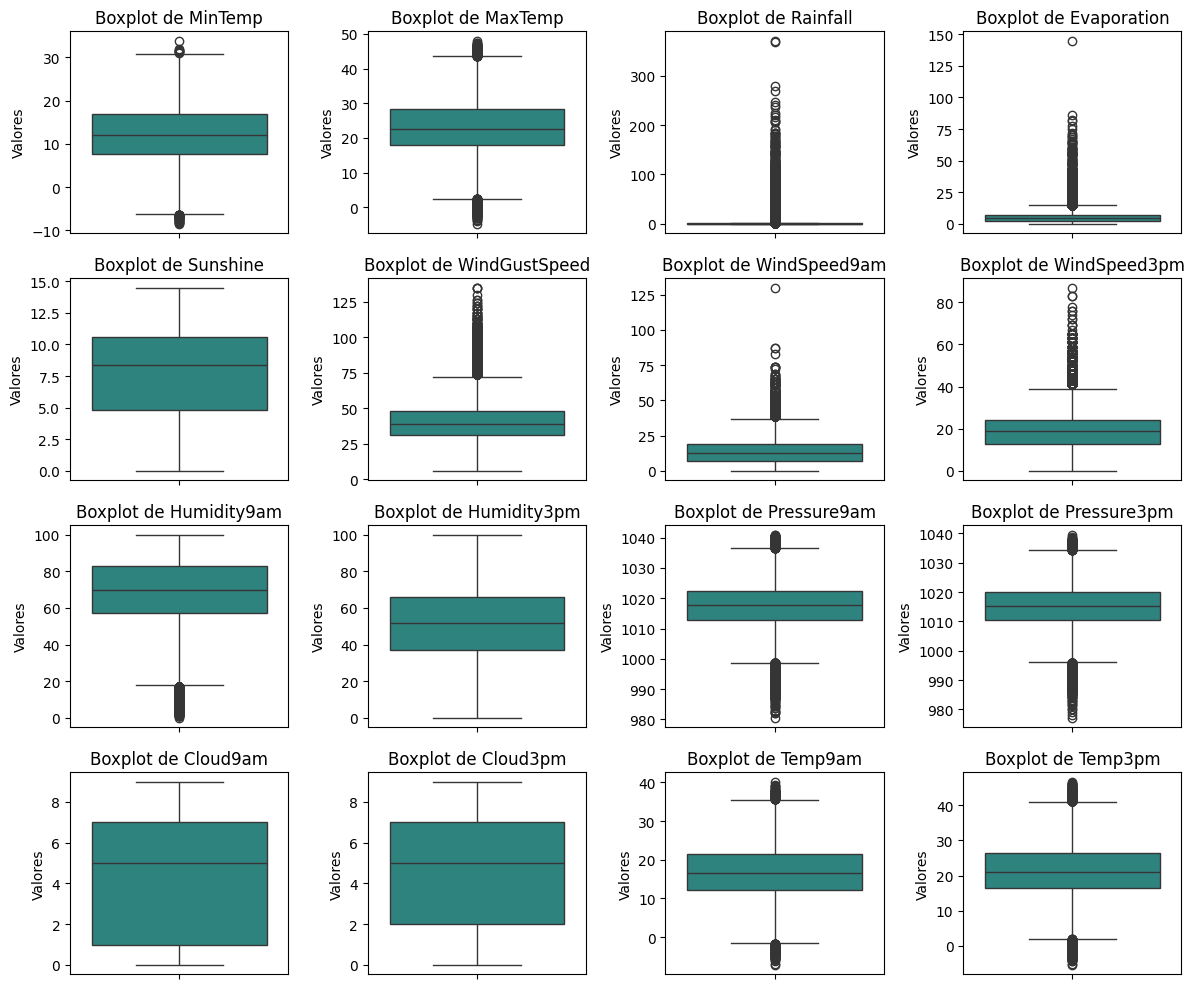

In [11]:
columnas = data_num.columns

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(columnas):
    sns.boxplot(y=data_num[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('Valores')

plt.tight_layout()
plt.show()

**Grupo de Temperaturas (MinTemp, MaxTemp, Temp9am, Temp3pm)**

Todas las variables de temperatura muestran distribuciones bastante simétricas. MaxTemp es casi perfectamente simétrica. MinTemp, en cambio, tiene una ligera asimetría izquierda (cola izquierda), con varios outliers en el extremo frío. Esto sugiere que las temperaturas mínimas inusualmente bajas son más comunes que las máximas inusualmente altas.

Temp9am vs Temp3pm: Ambas son muy simétricas, parecidas a MaxTemp. Tienen outliers en ambos extremos, lo cual es normal para mediciones de temperatura.

**Grupo de Humedad (Humidity9am, Humidity3pm)**

Humidity9am: Muestra una fuerte asimetría izquierda. La "caja" está aplastada en la parte superior del gráfico, lo que significa que la mayoría de las mañanas la humedad es muy alta (entre 70% y 90%). Los outliers son todos valores bajos.

Humidity3pm: Es la variable más simétrica y "limpia" de todas. Tiene una distribución casi normal, centrada alrededor del 50%-60%, y casi sin outliers.

Los datos muestran un patrón: la humedad es alta y poco variable por la mañana, pero baja y se "normaliza" por la tarde.

**Grupo de Presión Atmosférica (Pressure9am, Pressure3pm)**

Ambas presentan una clara asimetría izquierda. La mediana está en la mitad superior de la caja, y el bigote inferior es mucho más largo. Ambas tienen una fuerte presencia de outliers en el extremo inferior.

**Grupo de Viento (WindGustSpeed, WindSpeed9am, WindSpeed3pm)**

Todas tienen una fuerte asimetría derecha (cola derecha). La "caja" está comprimida en valores bajos, lo que indica que la mayoría del tiempo el viento es leve. Todas tienen una enorme cantidad de outliers en el extremo superior. Esos outliers representan los días de viento o ráfagas fuertes.

9am vs 3pm: La mediana y la caja de WindSpeed3pm están ligeramente más altas que en WindSpeed9am, sugiriendo que, en general, hay más viento por la tarde.

**Grupo de Agua (Rainfall, Evaporation)**

Rainfall: La "caja" (el 50% central de los datos) es una línea plana en cero. Esto significa que al menos el 75% de los días no llueve nada. Los outliers son la lluvia.

Evaporation: Similar a Rainfall, la caja está totalmente comprimida en la parte inferior. La mayoría de los valores son muy bajos.

**Grupo de Cielo (Sunshine, Cloud9am, Cloud3pm)**

Sunshine: distribución bimodal. La caja está aplastada en la parte superior (días de mucho sol), y el bigote inferior se extiende hasta 0 (días sin sol).

Cloud9am y Cloud3pm: No tienen outliers y los bigotes se extienden por todo el rango (de 0 a 8 o 9).

Detalle a tener en cuenta: Cloud9am y Cloud3pm son variables discretas (probablemente "octas" de cielo cubierto, de 0 a 8).


Detalles sobre las columnas categóricas.

In [12]:
data_cat = data[['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']]

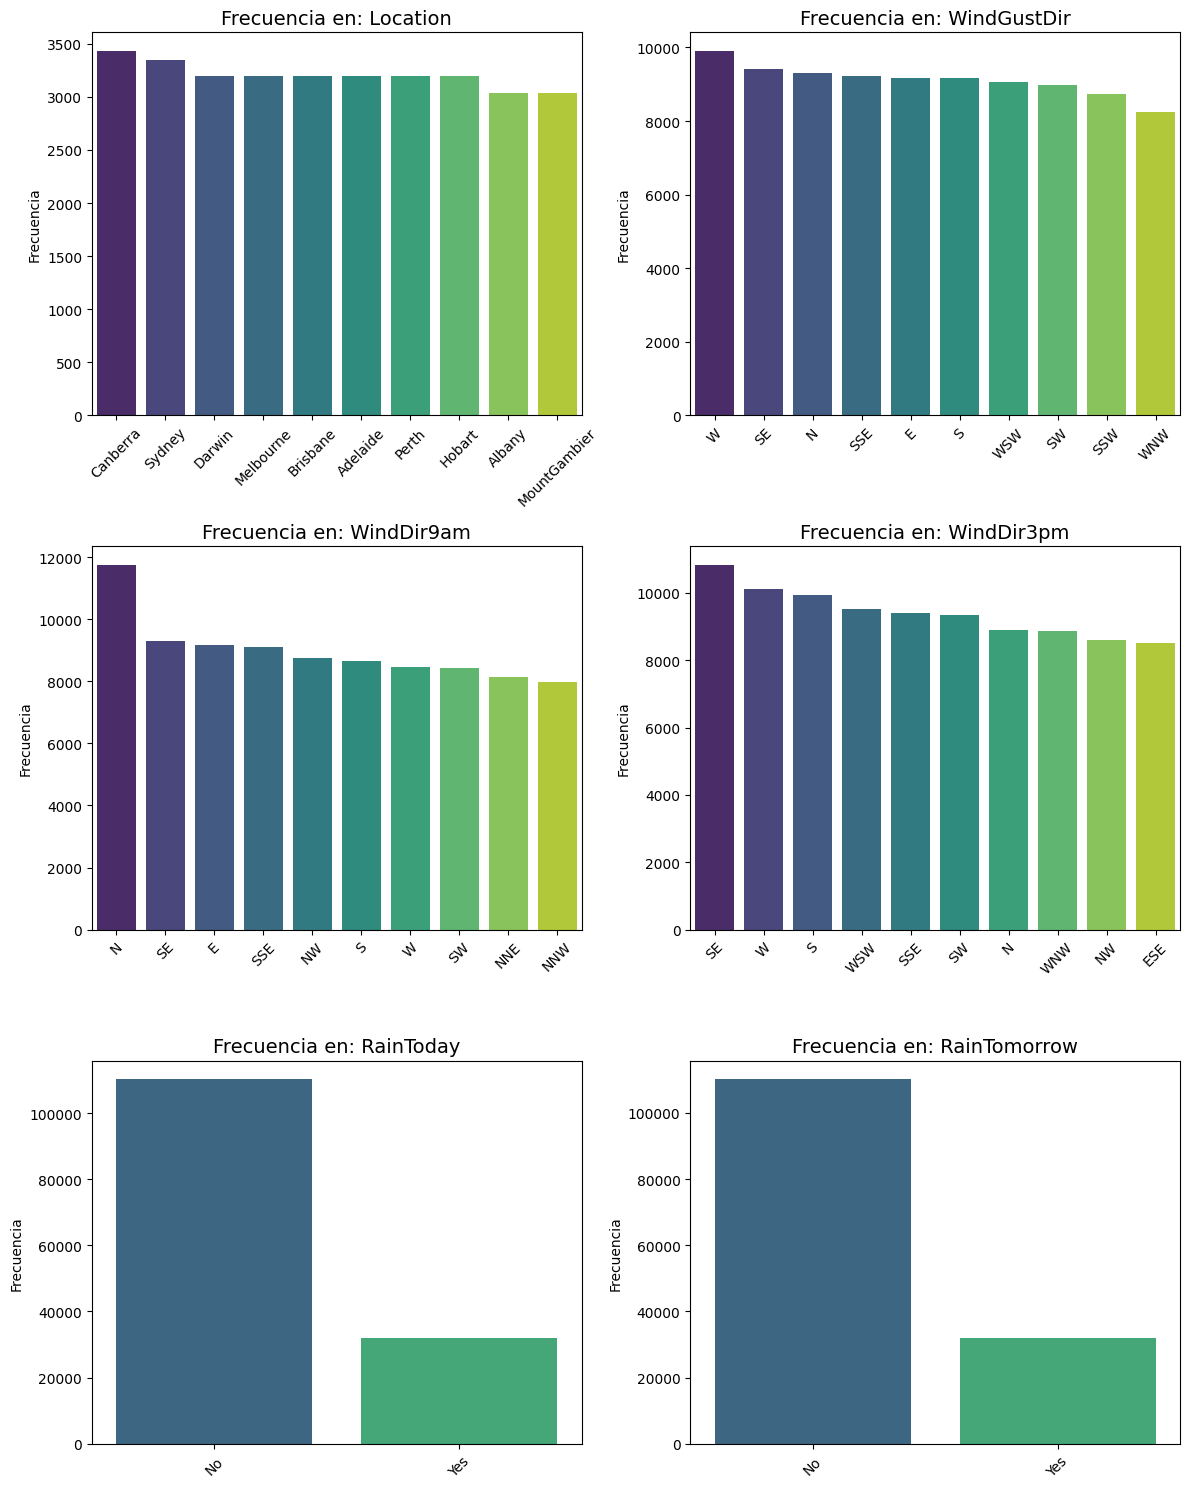

In [13]:
import math

n_cols = 2
n_rows = math.ceil(data_cat.shape[1] / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(data_cat.columns):
    top_cat = data_cat[col].value_counts().nlargest(10)
    
    sns.barplot(x=top_cat.index, y=top_cat.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Frecuencia en: {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Las variables categóricas relacionadas a WindDir y WindGus se dividen en los puntos cardinales de los cuales provienen los vientos. No parece hacer categorías sin valores. Por otro lado, las variables relacionadas a Rain solo tienen dos categorías que podrían ser transformadas en numéricas 1/0 para su uso en un modelo predictivo.

En este sentido, ya que **RainTomorrow** va a ser la variable objetivo, se puede suponer que está desbalanceada al haber más datos de 'No' que de 'Yes'. Esto indica que posiblemente deberá trabajarse para que no afecte a las predicciones.

---

### División del dataset en train-val-test

In [14]:
from sklearn.model_selection import train_test_split

Teniendo en cuenta el análisis sobre los datos nulos por columna visto previamente, se resuelve que imputar a las columnas que tienen 40% o más de nulos, no tiene sentido. Por lo tanto, se eliminarán de las variables predictoras (X). Asimismo, solo se eliminarán 3267 registros nulos de 'RainTomorrow' (futura variable objetivo) para que no cause problemas en el split. Esto representaría el apróx. 2,25% de los registros del dataset original.

In [15]:
data['RainTomorrow'].isna().sum()

3267

In [16]:
data = data.dropna(subset=['RainTomorrow'])

In [17]:
X = data.drop(columns=['RainTomorrow', 'Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am'], axis=1)
Y = data['RainTomorrow']

In [18]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val)

# Proporción final: X_train: 60%, X_val: 20%, X_test: 20%

In [19]:
print(f"""Conjunto de entrenamiento: x_train: {X_train.shape}, y_train: {y_train.shape[0]}
Conjunto de validación: x_val: {X_val.shape}, y_val: {y_val.shape[0]}
Conjunto de prueba: x_test: {X_test.shape}, y_test: {y_test.shape[0]}""")

Conjunto de entrenamiento: x_train: (85315, 18), y_train: 85315
Conjunto de validación: x_val: (28439, 18), y_val: 28439
Conjunto de prueba: x_test: (28439, 18), y_test: 28439


Se transforman los valores de la variable objetivo y RainToday en formato numérico para facilitar el funcionamiento del futuro modelo.

In [20]:
y_train = y_train.replace({'Yes': 1, 'No': 0}).astype(int)
y_val = y_val.replace({'Yes': 1, 'No': 0}).astype(int)
y_test = y_test.replace({'Yes': 1, 'No': 0}).astype(int)

In [21]:
if 'RainToday' in X_train.columns and X_train['RainToday'].dtype == 'object':
    dic = {'Yes': 1, 'No': 0}
    X_train['RainToday'] = X_train['RainToday'].map(dic)
    X_val['RainToday'] = X_val['RainToday'].map(dic)
    X_test['RainToday'] = X_test['RainToday'].map(dic)

---

### Imputación de datos faltantes y transformación de datos

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn import set_config

Como aún quedan columnas con nulos, se dividirán para imputarlas por separado, según su naturaleza vista en el EDA.

In [23]:
colum_num = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Rainfall',
                  'MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm', 
                  'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

colum_categ = ['WindDir9am', 'WindDir3pm', 'WindGustDir', 'RainToday']

In [24]:
set_config(transform_output="pandas")

In [25]:
imputador = ColumnTransformer(
    transformers=[
        ('num_imputer', SimpleImputer(strategy='median'), colum_num),
        ('cat_imputer', SimpleImputer(strategy='most_frequent'), colum_categ) # Se agrega de forma preventiva
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

Las variables categóricas se imputan por la moda y las numéricas, por la mediana. Se aplican los cambios a X_train y se transforman los demás conjuntos X.

In [26]:
imputador.fit(X_train)

X_train = imputador.transform(X_train)
X_val = imputador.transform(X_val)
X_test = imputador.transform(X_test)

Se aplica una transformación logarítmica (específicamente np.log1p) a las variables WindGustSpeed, WindSpeed9am, WindSpeed3pm y Rainfall. Esta decisión se basa en el EDA, el cual reveló que dichas variables poseían una fuerte asimetría positiva (cola a la derecha).

In [27]:
cols_transf_log = ['WindGustSpeed', 'WindSpeed9am', 
                   'WindSpeed3pm', 'Rainfall']

X_train[cols_transf_log] = np.log1p(X_train[cols_transf_log])
X_val[cols_transf_log] = np.log1p(X_val[cols_transf_log])
X_test[cols_transf_log] = np.log1p(X_test[cols_transf_log])

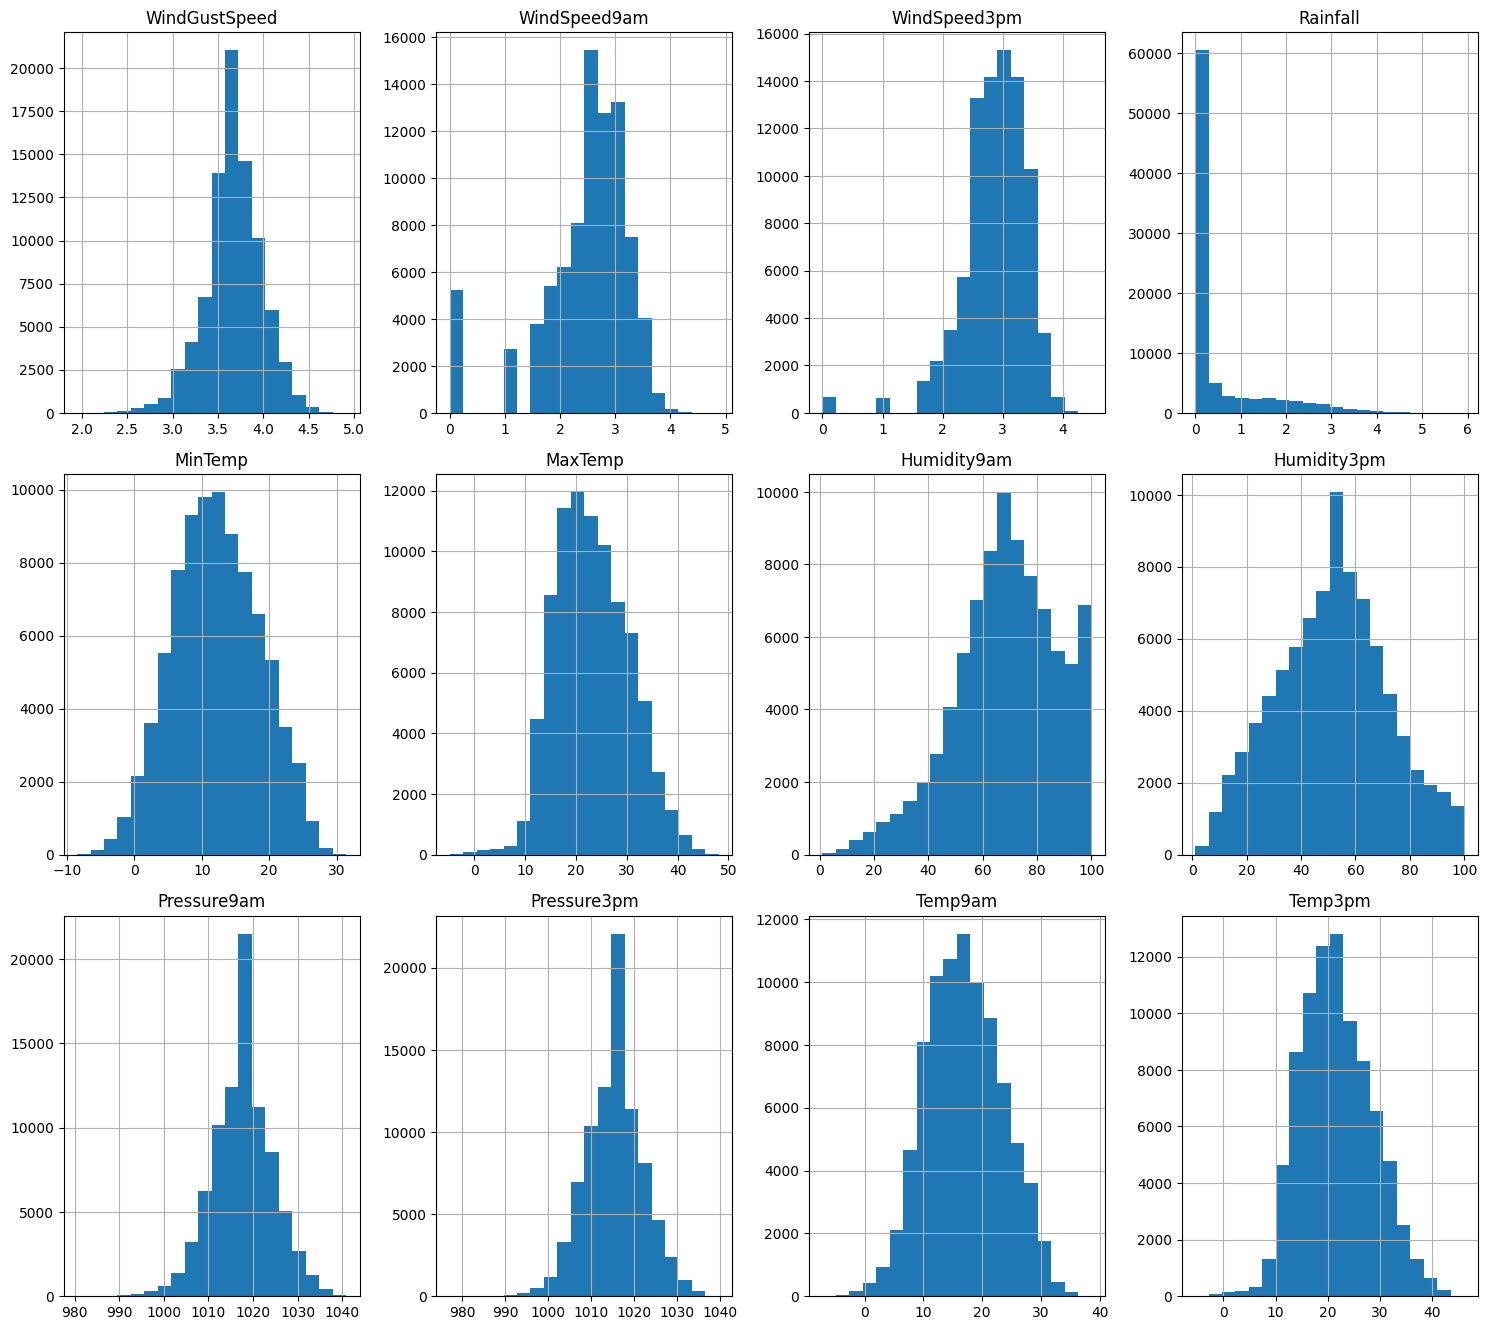

In [28]:
X_train.hist(figsize=(15, 22), bins=20, layout=(5, 4))
plt.tight_layout()
plt.show()

Las distribuciones de las variables de viento (WindGustSpeed, etc.) se volvieron mucho más simétricas y centradas. En Rainfall, aunque se mantiene una gran cantidad de ceros, el impacto de los valores extremos de lluvia fue drásticamente reducido, agrupándolos en un rango mucho más manejable.

---

### Creación de variables
Se chequea cómo quedó el dataset hasta esta instancia. A continuación, se procede a crear variables nuevas desde Date y dummies sobre todas las variables categóricas.

In [29]:
X_train.head()

,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Rainfall,MinTemp,MaxTemp,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,WindDir9am,WindDir3pm,WindGustDir,RainToday,Date,Location
76253,3.737670,2.995732,3.044522,1.722767,10.3,12.2,71.0,62.0,1016.6,1017.3,10.8,10.7,S,SW,S,1.0,2012-07-27,Portland
73930,3.526361,2.079442,2.639057,0.000000,-0.4,11.9,91.0,46.0,1032.9,1030.8,2.4,11.2,SSW,S,SSE,0.0,2014-08-11,Nhil
24746,3.850148,2.772589,3.295837,0.182322,10.5,17.5,49.0,44.0,1017.7,1015.2,14.2,16.0,W,SW,WSW,0.0,2010-08-12,Penrith
82735,3.970292,2.772589,3.044522,0.000000,15.0,24.2,23.0,99.0,1005.1,1002.4,24.1,21.1,NNW,NW,NW,0.0,2014-01-01,Dartmoor
24838,3.583519,1.945910,2.772589,0.182322,16.0,33.2,73.0,32.0,1017.7,1015.2,22.1,32.6,SSW,NE,ENE,0.0,2010-11-12,Penrith


Se crea season para solo guiar al modelo por la temporada por meses.

In [30]:
estaciones = {
    12: 'Verano', 1: 'Verano', 2: 'Verano',
    3: 'Otoño', 4: 'Otoño', 5: 'Otoño',
    6: 'Invierno', 7: 'Invierno', 8: 'Invierno',
    9: 'Primavera', 10: 'Primavera', 11: 'Primavera'}

In [31]:
for conj in [X_train, X_val, X_test]:
    conj['Date'] = pd.to_datetime(conj['Date'])

    conj['season'] = conj['Date'].dt.month.map(estaciones)
    conj.drop(columns=['Date'], inplace=True)

Las variables de vientos y season pasan a ser dummies en todos los conjuntos.

In [32]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
cols_categ = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'season']
for df in [X_train, X_val, X_test]:
    df[cols_categ] = df[cols_categ].astype(str)

In [34]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore') 
ohe.fit(X_train[cols_categ])

OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [35]:
ohe_nombres = ohe.get_feature_names_out(cols_categ)

data_final_list = []

for df in [X_train, X_val, X_test]:
    cols_enc = ohe.transform(df[cols_categ])

    data_ohe = pd.DataFrame(cols_enc, columns=ohe_nombres, index=df.index)

    data_procesada = df.drop(columns=cols_categ)

    data_final = pd.concat([data_procesada, data_ohe], axis=1)
    data_final_list.append(data_final)

In [36]:
X_train = data_final_list[0]
X_val = data_final_list[1]
X_test = data_final_list[2]

Se continúa con la normalización de la variable Location, ya que es muy importante para asegurarse que solo se trabajará con ciudades de Australia.

In [37]:
from geonamescache import GeonamesCache

In [38]:
gc = GeonamesCache()

def coords_aus(nombre_ciudad):
    """
    Busca una ciudad por su nombre y devuelve las coordenadas
    solo si se encuentra en Australia (countrycode 'AU').
    """
    posibles_ciudades = gc.get_cities_by_name(nombre_ciudad)
    
    for dict_ciudad in posibles_ciudades:
        data_ciudad = list(dict_ciudad.values())[0] 
        
        if data_ciudad['countrycode'] == 'AU':
            return (data_ciudad['latitude'], data_ciudad['longitude'])
    
    return None

In [39]:
ciudades_unicas = X_train['Location'].unique()
coord_map = {ciudad: coords_aus(ciudad) for ciudad in ciudades_unicas}

In [40]:
for df in [X_train, X_val, X_test]:
    df['coords'] = df['Location'].map(coord_map)
    
    df['latitude'] = df['coords'].apply(lambda x: x[0] if x is not None else None)
    df['longitude'] = df['coords'].apply(lambda x: x[1] if x is not None else None)
    df.drop(columns=['coords'], inplace=True)

Visualización de ciudades en mapa

In [41]:
import geopandas as gpd
import contextily as ctx

In [42]:
def crear_geodf(df, lon_col="longitude", lat_col="latitude"):
    """
    Convierte un DataFrame con columnas de latitud/longitud
    en un GeoDataFrame en proyección métrica (EPSG:3857)
    """
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"  # coordenadas geográficas
    )
    return gdf.to_crs(epsg=3857)

In [43]:
gdf_train = crear_geodf(X_train)

In [44]:
def graf_mapa(geodf, titulo):
    fig, ax = plt.subplots(figsize=(10, 8))
    geodf.plot(ax=ax, color='red', markersize=60)

    # Mapa base
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    ax.set_xlim(geodf.total_bounds[0] - 1e6, geodf.total_bounds[2] + 1e6)
    ax.set_ylim(geodf.total_bounds[1] - 1e6, geodf.total_bounds[3] + 1e6)

    ax.set_title(titulo, fontsize=14)
    plt.show()

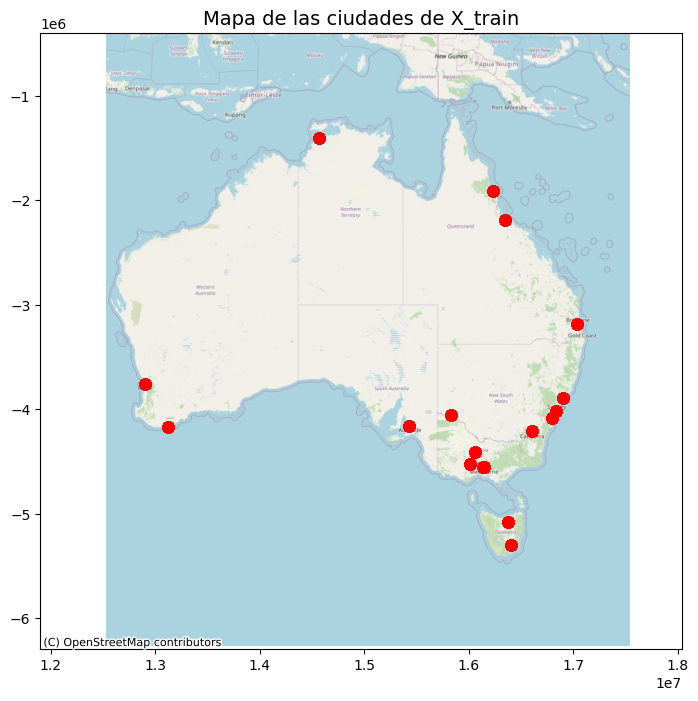

In [45]:
titulo = 'Mapa de las ciudades de X_train'
graf_mapa(gdf_train, titulo)

Si bien el mapa graficó las ciudades sin aparentes problemas, se verifica si hay datos nulos entre las coordenadas de ciudades.

In [46]:
X_train[['Location', 'latitude', 'longitude']]

,Location,latitude,longitude
76253,Portland,NaN,NaN
73930,Nhil,NaN,NaN
24746,Penrith,NaN,NaN
82735,Dartmoor,NaN,NaN
24838,Penrith,NaN,NaN
...,...,...,...
37918,WaggaWagga,NaN,NaN
68249,Melbourne,-37.81400,144.96332
81886,Dartmoor,NaN,NaN
85314,Brisbane,-27.46794,153.02809


Sí hay ciudades que no fueron encontradas en la función que debía ubicar sus coordenadas. Se corrije de manera manual.

In [47]:
ciudades_faltantes = X_train[X_train['latitude'].isnull()]['Location'].unique()
ciudades_faltantes

array(['Portland', 'Nhil', 'Penrith', 'Dartmoor', 'MountGinini',
       'CoffsHarbour', 'Nuriootpa', 'Sale', 'Cobar', 'Albury',
       'SalmonGums', 'Watsonia', 'BadgerysCreek', 'GoldCoast',
       'NorfolkIsland', 'PerthAirport', 'SydneyAirport', 'Moree',
       'PearceRAAF', 'Woomera', 'Tuggeranong', 'NorahHead', 'Walpole',
       'MelbourneAirport', 'MountGambier', 'WaggaWagga', 'Katherine',
       'Witchcliffe', 'AliceSprings', 'Williamtown', 'Uluru'],
      dtype=object)

In [48]:
coord_map = {
    # Ciudades que ya funcionaban
    'Melbourne': (-37.81400, 144.96332),
    'Brisbane': (-27.46794, 153.02809),
    'Perth': (-31.95224, 115.8614),
    # --- Ciudades que faltaban ---
    'Portland': (-38.3398, 141.6032),
    'Nhil': (-36.3333, 141.6500),
    'Penrith': (-33.7510, 150.6940),
    'Dartmoor': (-37.9220, 141.2742),
    'MountGinini': (-35.5297, 148.7750),
    'CoffsHarbour': (-30.2963, 153.1140),
    'Nuriootpa': (-34.4699, 138.9950),
    'Sale': (-38.1042, 147.0667),
    'Cobar': (-31.4983, 145.8344),
    'Albury': (-36.0737, 146.9135),
    'SalmonGums': (-32.9806, 121.6444),
    'Watsonia': (-37.7120, 145.0830),
    'BadgerysCreek': (-33.8887, 150.7403),
    'GoldCoast': (-28.0167, 153.4000),
    'NorfolkIsland': (-29.0408, 167.9547),
    'PerthAirport': (-31.9403, 115.9669),
    'SydneyAirport': (-33.9399, 151.1753),
    'Moree': (-29.4632, 149.8431),
    'PearceRAAF': (-31.6739, 116.0150),
    'Woomera': (-31.2010, 136.8340),
    'Tuggeranong': (-35.4211, 149.0961),
    'NorahHead': (-33.2819, 151.5714),
    'Walpole': (-34.9750, 116.7306),
    'MelbourneAirport': (-37.6733, 144.8433),
    'MountGambier': (-37.8290, 140.7798),
    'WaggaWagga': (-35.1189, 147.3694),
    'Katherine': (-14.4647, 132.2639),
    'Witchcliffe': (-34.0261, 115.1017),
    'AliceSprings': (-23.6980, 133.8807),
    'Williamtown': (-32.8150, 151.8425),
    'Uluru': (-25.3444, 131.0369)
}

In [49]:
lat_map = {city: coords[0] for city, coords in coord_map.items()}
lon_map = {city: coords[1] for city, coords in coord_map.items()}


for df in [X_train, X_val, X_test]:
    idx_nulos = df['latitude'].isnull()
    df.loc[idx_nulos, 'latitude'] = df.loc[idx_nulos, 'Location'].map(lat_map)
    df.loc[idx_nulos, 'longitude'] = df.loc[idx_nulos, 'Location'].map(lon_map)

In [50]:
X_train[['latitude', 'longitude']].isnull().sum()

latitude     0
longitude    0
dtype: int64

Se continúa con la clusterización de las regiones. Se hipotetiza que se propia dividir el mapa en cuatro regiones (norte, sur, este y oeste) pero se verificará con el método del codo.

In [51]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [52]:
from sklearn.cluster import KMeans

In [53]:
x = X_train[['latitude', 'longitude']]

d:\Programas\anaconda3\envs\Python_ML\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


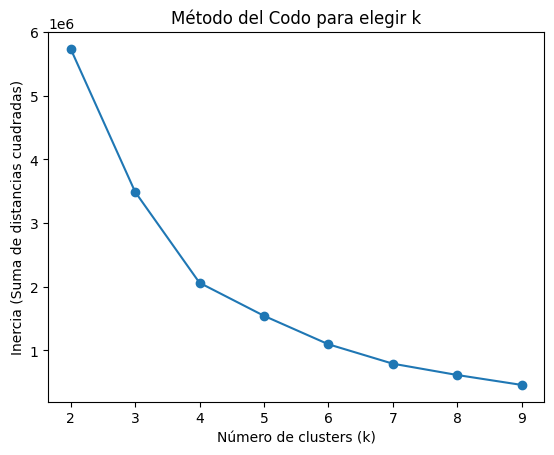

In [54]:
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(x)
    inertias.append(km.inertia_)

plt.plot(range(2, 10), inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Suma de distancias cuadradas)')
plt.title('Método del Codo para elegir k')
plt.show()

El método del codo demuestra que es mejor 6 que 4. Se graficará esta idea.

In [55]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

X_train['region_cluster'] = kmeans.fit_predict(x)
X_val['region_cluster'] = kmeans.predict(X_val[['latitude', 'longitude']])
X_test['region_cluster'] = kmeans.predict(X_test[['latitude', 'longitude']])

Graficación de resultados de clusters

In [56]:
gdf = crear_geodf(X_train)

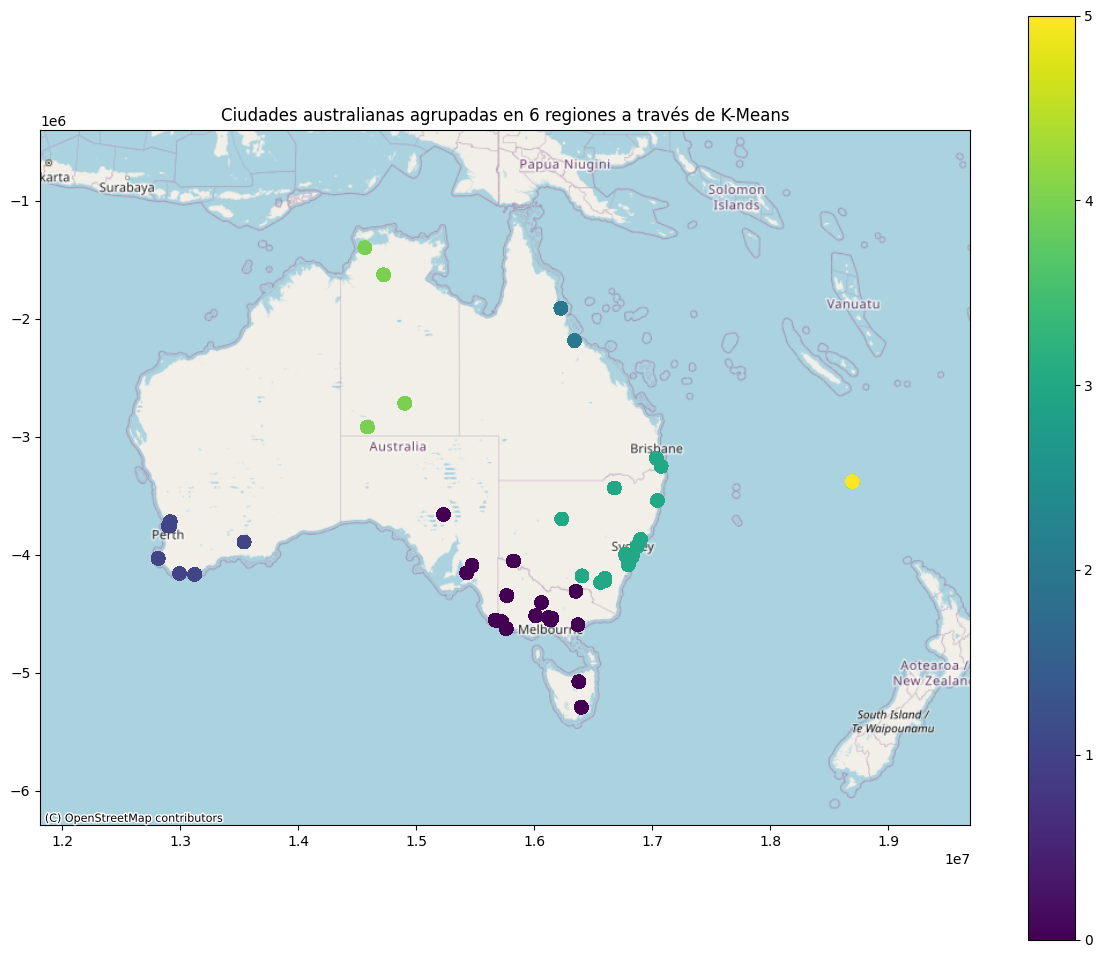

In [57]:
fig, ax = plt.subplots(figsize=(15, 12))
gdf.plot(ax=ax, column="region_cluster", legend=True, markersize=80, alpha=0.9)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_xlim(gdf.total_bounds[0] - 1e6, gdf.total_bounds[2] + 1e6)
ax.set_ylim(gdf.total_bounds[1] - 1e6, gdf.total_bounds[3] + 1e6)
ax.set_title(f"Ciudades australianas agrupadas en {k} regiones a través de K-Means")
plt.show()

Se eliminan las columnas que se consideran innecesarias y se procede a trabajar sobre otras potencialmente útiles que no fueron observadas, como Date.

In [58]:
for df in [X_train, X_val, X_test]:
    df.drop(columns=['Location','latitude', 'longitude'], inplace=True)

Con el fin de chequear la relación entre las variables numéricas resultantes post imputación y transformación, se verifica la correlación entre ellas. Esto permitirá eliminar columnas antes del desarrollo del modelo predictivo.

In [59]:
colum_numer_final = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Rainfall', 'MinTemp',
       'MaxTemp', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
       'Temp9am', 'Temp3pm']

corr_matrix = X_train[colum_numer_final].corr()

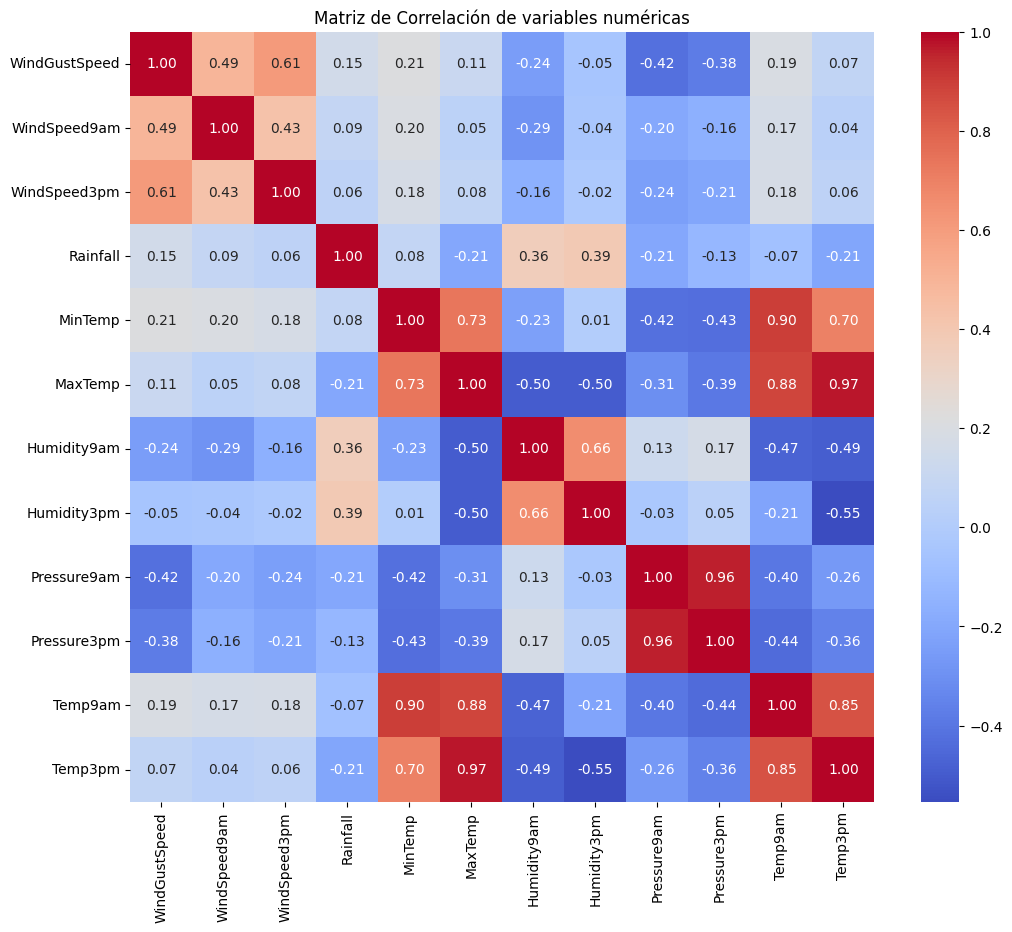

In [60]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de variables numéricas')
plt.show()

Como se observa en el anterior análisis, se encuentra mucha correlación entre Pressure9am, Pressure3pm, Temp9am, Temp3pm, MinTemp y MaxTemp. Se procede a probar modelos para descartar o no, alguna de estas variables.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline

In [62]:
X_train_df = pd.DataFrame(X_train, columns=['Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'MinTemp', 'MaxTemp'])
X_test_df = pd.DataFrame(X_test, columns=['Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'MinTemp', 'MaxTemp'])

X1_train = X_train_df[['Pressure9am', 'Pressure3pm', 'Temp9am']]
X2_train = X_train_df[['Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']]
X3_train = X_train_df[['Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'MinTemp', 'MaxTemp']]
X1_test = X_test_df[['Pressure9am', 'Pressure3pm', 'Temp9am']]
X2_test = X_test_df[['Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']]
X3_test = X_test_df[['Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'MinTemp', 'MaxTemp']]
X4_train = X_train_df[['Pressure3pm', 'MinTemp', 'MaxTemp']]
X4_test = X_test_df[['Pressure3pm', 'MinTemp', 'MaxTemp']]

In [63]:
modelo1 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X1_train, y_train)
modelo2 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X2_train, y_train)
modelo3 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X3_train, y_train)
modelo4 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X4_train, y_train)

# predicciones en test
y_pred1 = modelo1.predict(X1_test)
y_pred2 = modelo2.predict(X2_test)
y_pred3 = modelo3.predict(X3_test)
y_pred4 = modelo4.predict(X4_test)

# evaluación en este caso del ACCURACY
acc1 = accuracy_score(y_test, y_pred1)
acc2 = accuracy_score(y_test, y_pred2)
acc3 = accuracy_score(y_test, y_pred3)
acc4 = accuracy_score(y_test, y_pred4)

print(f"Modelo 1: Acc = {acc1:.3f}")
print(f"Modelo 2: Acc = {acc2:.3f}")
print(f"Modelo 3 (todas las var.): Acc = {acc3:.3f}")
print(f"Modelo 4 (simplificado con 3 var.): Acc = {acc4:.3f}")

Modelo 1: Acc = 0.782
Modelo 2: Acc = 0.800
Modelo 3 (todas las var.): Acc = 0.809
Modelo 4 (simplificado con 3 var.): Acc = 0.803


Usando la mitad de las variables (solo 3 en lugar de 6), se obtuvo prácticamente el mismo rendimiento (se perdió menos del 1% de accuracy). Esto confirma que Pressure9am, Temp9am y Temp3pm son mayormente "ruido" cuando se tiene Pressure3pm, MinTemp y MaxTemp. Se opta por las variables del modelo 4 y rever las correlaciones.

In [64]:
for df in [X_train, X_val, X_test]:
    df.drop(columns=['Pressure9am', 'Temp9am', 'Temp3pm'], inplace=True)

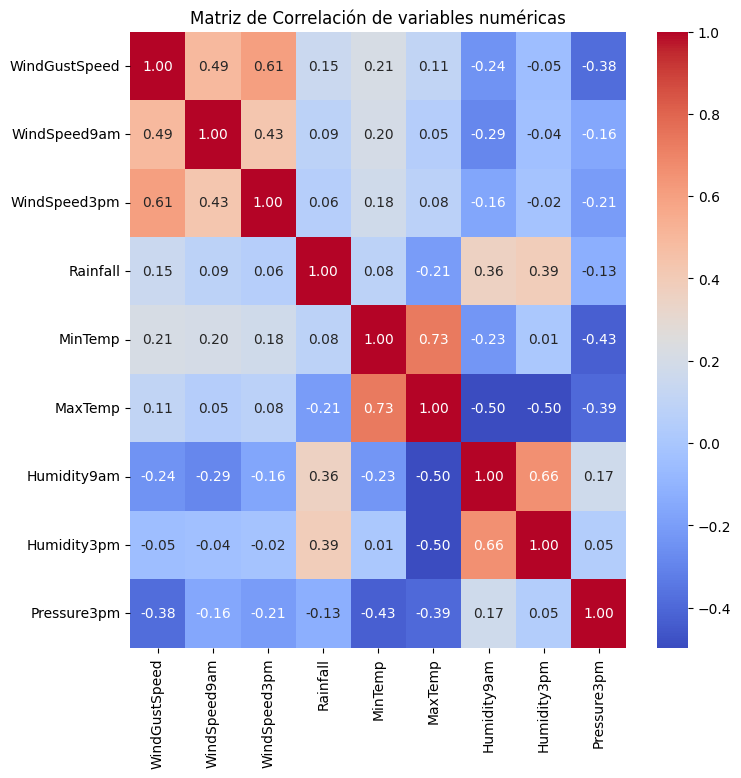

In [65]:
colum_numer_final_2 = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Rainfall', 'MinTemp',
       'MaxTemp', 'Humidity9am', 'Humidity3pm', 'Pressure3pm']

corr_matrix_2 = X_train[colum_numer_final_2].corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix_2, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de variables numéricas')
plt.show()

---

### Desarrollo de Modelo de Regresión Logística

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, PrecisionRecallDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from imblearn.over_sampling import SMOTE

Escalado de variables previo al modelado.

In [67]:
cols_a_escalar = ['WindGustSpeed','WindSpeed9am', 'WindSpeed3pm', 'Rainfall',
                'MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm', 'Pressure3pm']

scaler = StandardScaler()

In [68]:
scaler.fit(X_train[cols_a_escalar])

X_train[cols_a_escalar] = scaler.transform(X_train[cols_a_escalar])
X_val[cols_a_escalar] = scaler.transform(X_val[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

Se construye el modelo de regresión logística con algunos parámetros prefijados.

In [69]:
modelo_1 = LogisticRegression(
    C=0.1,
    random_state=42,
    class_weight='balanced')

Validación cruzada:

In [70]:
from sklearn.model_selection import cross_val_score

In [71]:
scores = cross_val_score(modelo_1, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)

print(f"F1 promedio en CV: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

F1 promedio en CV: 0.6063
Desviación estándar: 0.0049


In [72]:
modelo_1.fit(X_train, y_train)

LogisticRegression(C=0.1, class_weight='balanced', random_state=42)

**Modelo 1 (básico):**

Función para graficar:

In [73]:
def graficar_matriz_roc(modelo, X_val, y_val):
    y_pred_val = modelo.predict(X_val)
    y_prob_val = modelo.predict_proba(X_val)[:, 1]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    cm = confusion_matrix(y_val, y_pred_val)
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Si'])
    disp_cm.plot(cmap='Blues', values_format='d', ax=ax[0], colorbar=False)
    ax[0].set_title('Matriz de Confusión')

    fpr, tpr, thresholds = roc_curve(y_val, y_prob_val)
    roc_auc = auc(fpr, tpr)

    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
    ax[1].set_ylabel('True Positive Rate (Recall)')
    ax[1].set_title('Receiver Operating Characteristic (ROC)')
    ax[1].legend(loc="lower right")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [74]:
print("--- Evaluación Modelo Base (Validación) ---")
y_pred_val_base = modelo_1.predict(X_val)
print(classification_report(y_val, y_pred_val_base))

--- Evaluación Modelo Base (Validación) ---
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     22063
           1       0.50      0.75      0.60      6376

    accuracy                           0.78     28439
   macro avg       0.71      0.77      0.72     28439
weighted avg       0.82      0.78      0.79     28439



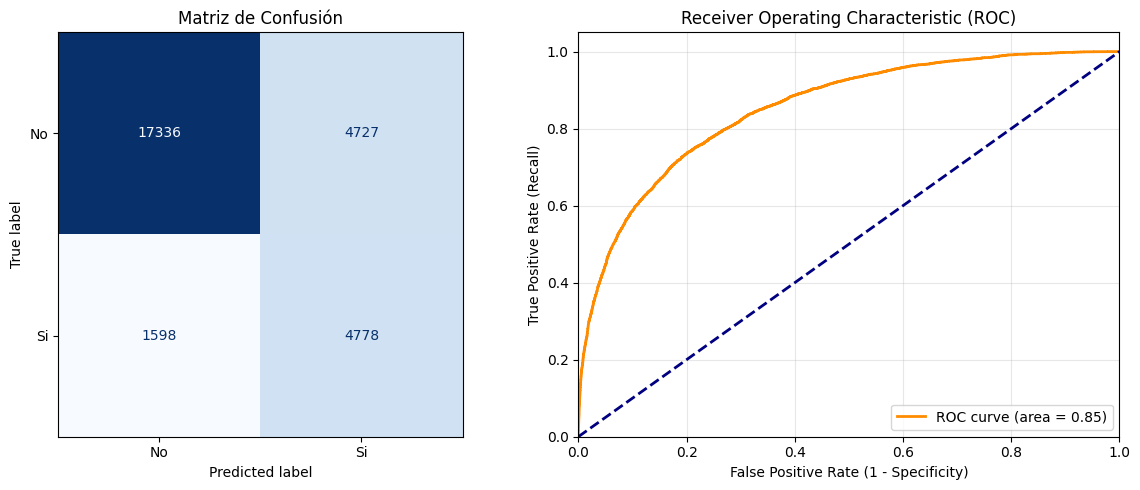

In [75]:
graficar_matriz_roc(modelo_1, X_val, y_val)

**Modelo 2 (Regresión Logística c/SMOTE):**

In [76]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

lr_smote = LogisticRegression(solver='liblinear', random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote_val = lr_smote.predict(X_val)

In [77]:
print("--- Informe de Clasificación (SMOTE - Validación) ---")
print(classification_report(y_val, y_pred_smote_val, target_names=['No Llueve (0)', 'Llueve (1)']))

--- Informe de Clasificación (SMOTE - Validación) ---
               precision    recall  f1-score   support

No Llueve (0)       0.91      0.78      0.84     22063
   Llueve (1)       0.50      0.75      0.60      6376

     accuracy                           0.78     28439
    macro avg       0.71      0.77      0.72     28439
 weighted avg       0.82      0.78      0.79     28439



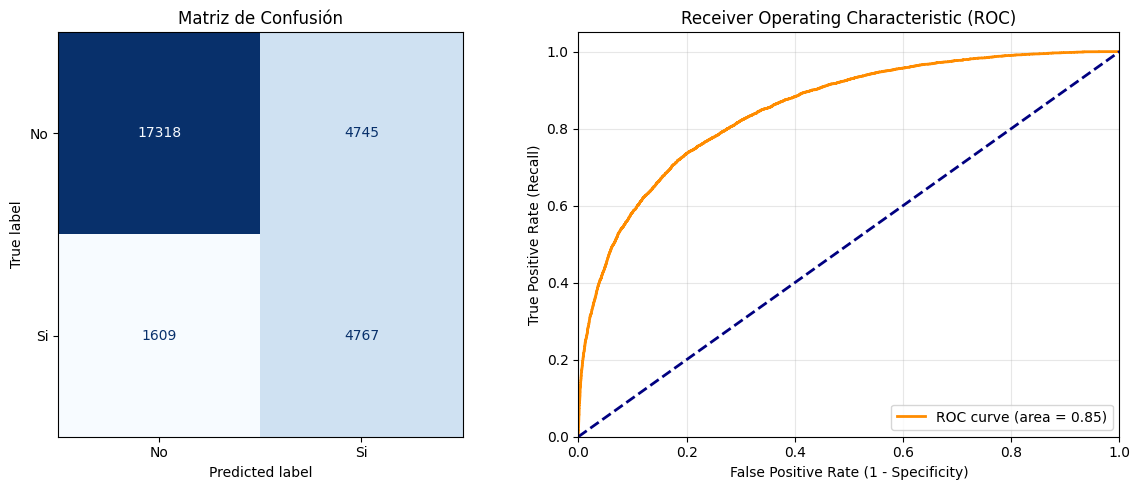

In [78]:
graficar_matriz_roc(lr_smote, X_val, y_val)

Umbrales:

In [79]:
y_prob_val_base = modelo_1.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_prob_val_base)

youden_index = tpr - fpr
best_threshold_idx = np.argmax(youden_index)
best_threshold = thresholds[best_threshold_idx]

print(f"Mejor umbral según Youden: {best_threshold:.4f}")

Mejor umbral según Youden: 0.5147


El umbral óptimo está muy cerca del valor por defecto (0.5). Esto significa que las probabilidades que predice el modelo son bastante realistas y no están sesgadas hacia un extremo.

---

**Modelo base (para comparar)**

In [80]:
from sklearn.dummy import DummyClassifier

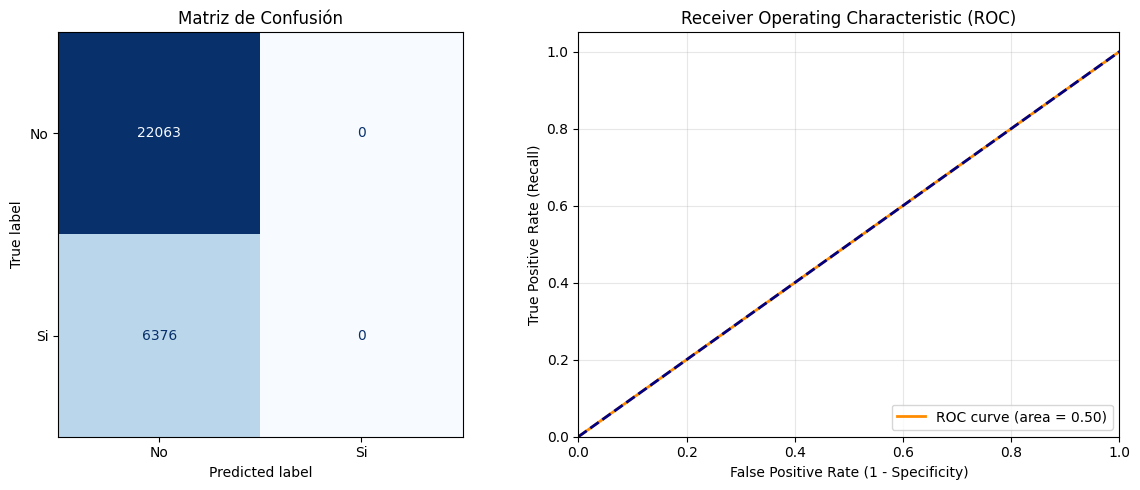

In [81]:
clasif_dummy = DummyClassifier(strategy="most_frequent", random_state=42)
clasif_dummy.fit(X_train, y_train)

graficar_matriz_roc(clasif_dummy, X_val, y_val)

**Modelo 3: Regresión Logistica Optimizada**

In [83]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform
import time

Se mejora el modelo base con RandomSearch para optimizar sus hiperparámetros. Se elige el solver "saga" para abrir la posibilidad de que RandomSearch pueda determinar entre Lasso, Ridge y ElasticNet como regularizaciones sin cerrar la posibilidad a ninguna.

In [84]:
param = [{'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['saga'],
        'C': loguniform(1e-3, 1e3),
        'l1_ratio': uniform(0, 1)}]

In [ ]:
random_search = RandomizedSearchCV(
    estimator=modelo_1,
    param_distributions=param,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42)

In [90]:
random_search.fit(X_train, y_train)
print("Mejores parámetros encontrados:", random_search.best_params_)
print("Mejor score:", random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros encontrados: {'C': 0.1767016940294795, 'l1_ratio': 0.9507143064099162, 'penalty': 'elasticnet', 'solver': 'saga'}
Mejor score: 0.8533422794426114


Se eligió RandomSearch por su rapidez y la posibilidad de evaluar parámetros más "detallados" considerando valores continuos en un margen de tiempo más rápido. Se guardan los hiperparámetros más óptimos y se continúa con el modelo de regresión logística.

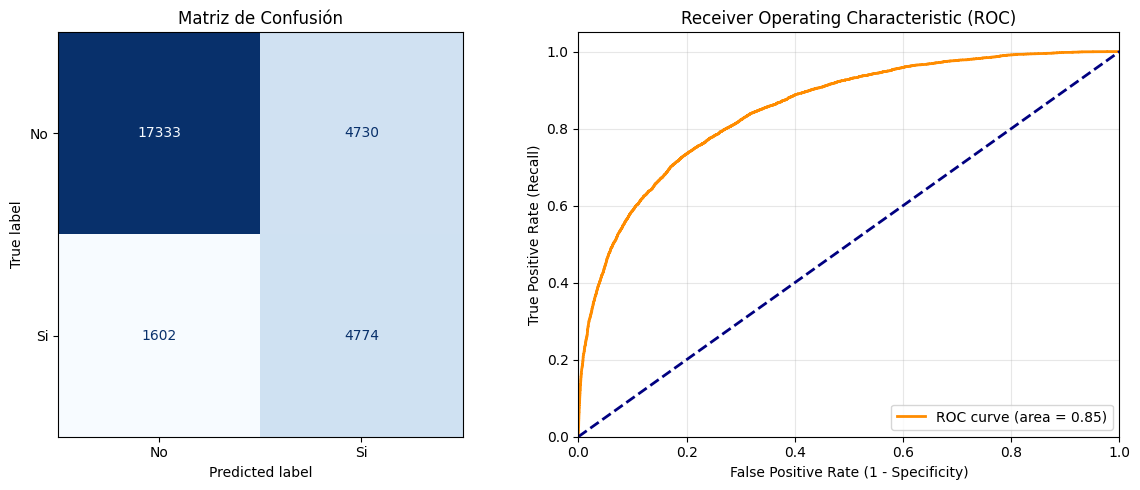

In [91]:
modelo_optimizado = random_search.best_estimator_
graficar_matriz_roc(modelo_optimizado, X_val, y_val)

### SHAP

In [85]:
import shap

**SHAP para modelo 1 (base):**

Gráficos globales.

In [ ]:
modelo_a_explicar = modelo_base
datos_background = X_train
datos_a_explicar = X_test

explainer_base = shap.LinearExplainer(modelo_a_explicar, datos_background)

shap_values_base = explainer_base.shap_values(datos_a_explicar)

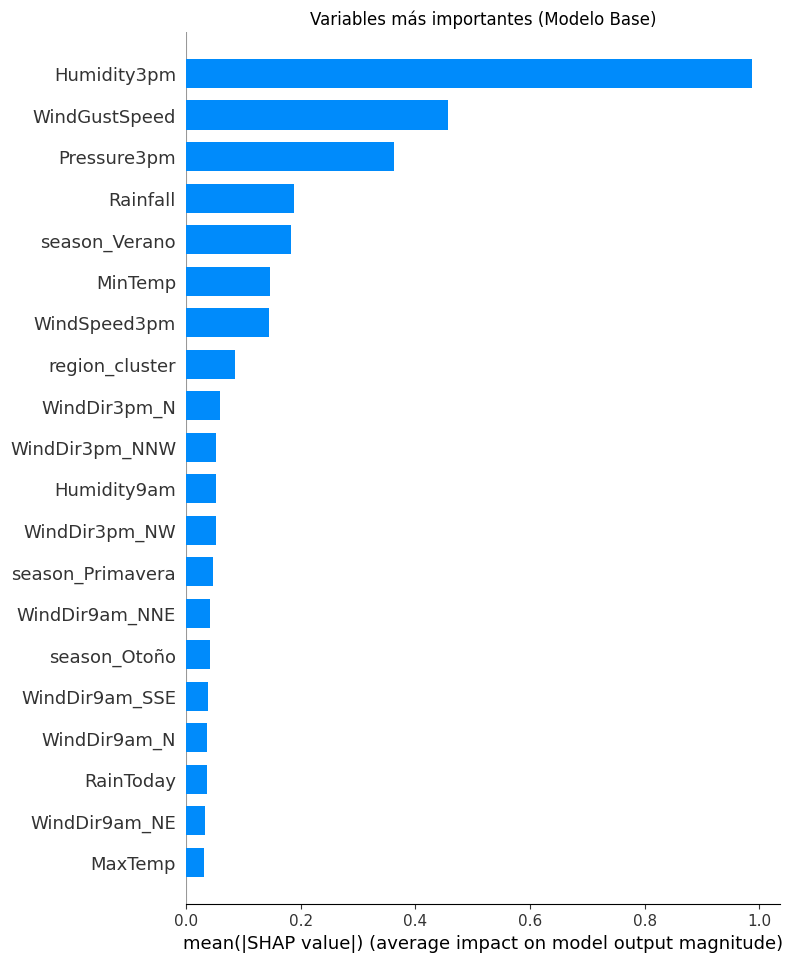

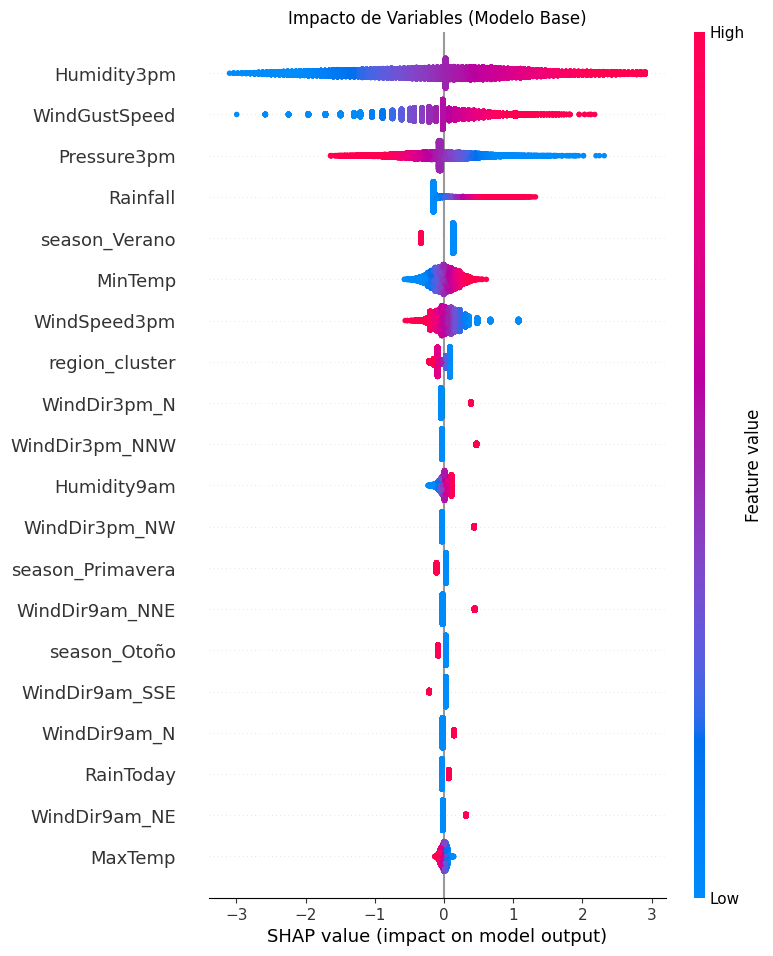

In [ ]:
plt.figure()
shap.summary_plot(
    shap_values_base.astype(float), 
    datos_a_explicar.astype(float), 
    plot_type="bar", 
    show=False
)
plt.title("Variables más importantes (Modelo Base)")

plt.figure()
shap.summary_plot(
    shap_values_base.astype(float), 
    datos_a_explicar.astype(float), 
    plot_type="dot", 
    show=False
)
plt.title("Impacto de Variables (Modelo Base)")
plt.show()

Gráficos locales.

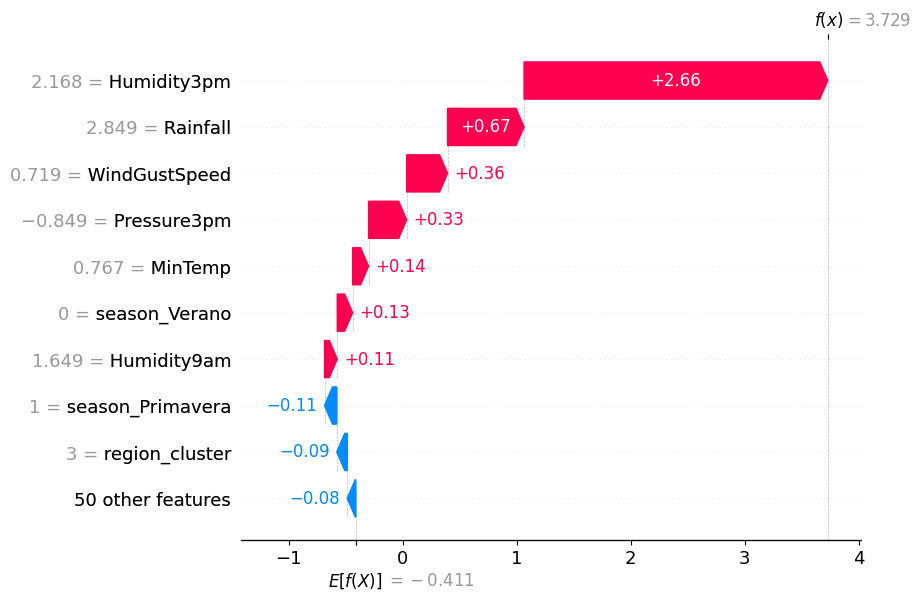

In [ ]:
i1, i2 = 0, 50
shap.initjs()

display(shap.force_plot(
    explainer_base.expected_value, 
    shap_values_base[i1,:].astype(float), 
    datos_a_explicar.iloc[i1,:].astype(float)
))

exp_obj_local = shap.Explanation(
    values=shap_values_base[i2,:],
    base_values=explainer_base.expected_value,
    data=datos_a_explicar.iloc[i2,:].values,
    feature_names=datos_a_explicar.columns)

shap.waterfall_plot(exp_obj_local)
plt.show()
plt.show()

**Conclusiones sobre lo visto del Modelo Base:**

A partir del análisis global con SHAP, se determinó que las variables Humidity3pm, Pressure3pm y WindGustSpeed son las más influyentes en las predicciones del modelo de regresión logística.
En particular, una humedad elevada y presión atmosférica baja aumentan considerablemente la probabilidad de lluvia, lo que es consistente con el comportamiento meteorológico real.

La variable season_Verano también mostró una contribución importante, indicando que la estación del año modifica el patrón de lluvias.
Factores como Rainfall previo y temperaturas mínimas aportan información adicional sobre la humedad ambiental.

Las variables relacionadas con la dirección del viento o el viento a media tarde tuvieron una contribución casi nula, por lo que podrían eliminarse sin afectar el rendimiento del modelo.

Este análisis demuestra que el modelo logra no solo un buen desempeño predictivo (AUC ≈ 0.85), sino también una coherencia física y explicativa: las variables más relevantes coinciden con los factores atmosféricos que realmente determinan la probabilidad de lluvia.

**SHAP para modelo 2 (optimizado por RandomSearch):**

In [ ]:
modelo_a_explicar = modelo_optimizado
datos_background = X_train
datos_a_explicar = X_test

explainer_base = shap.LinearExplainer(modelo_a_explicar, datos_background)

shap_values_base = explainer_base.shap_values(datos_a_explicar)

Gráficos Globales.

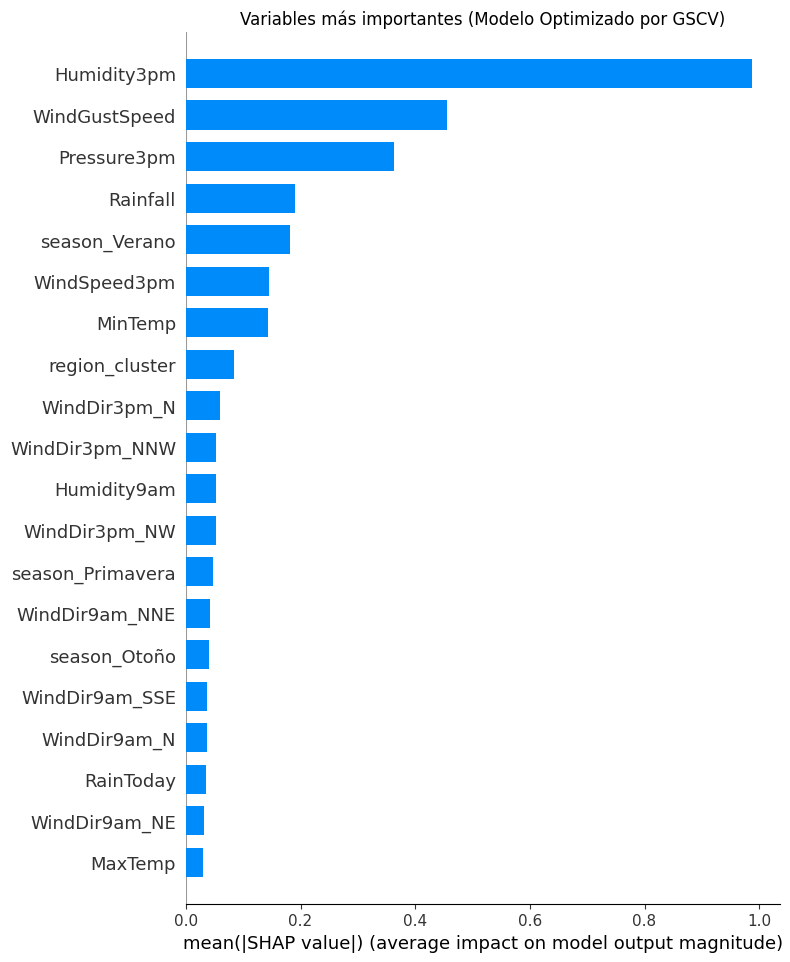

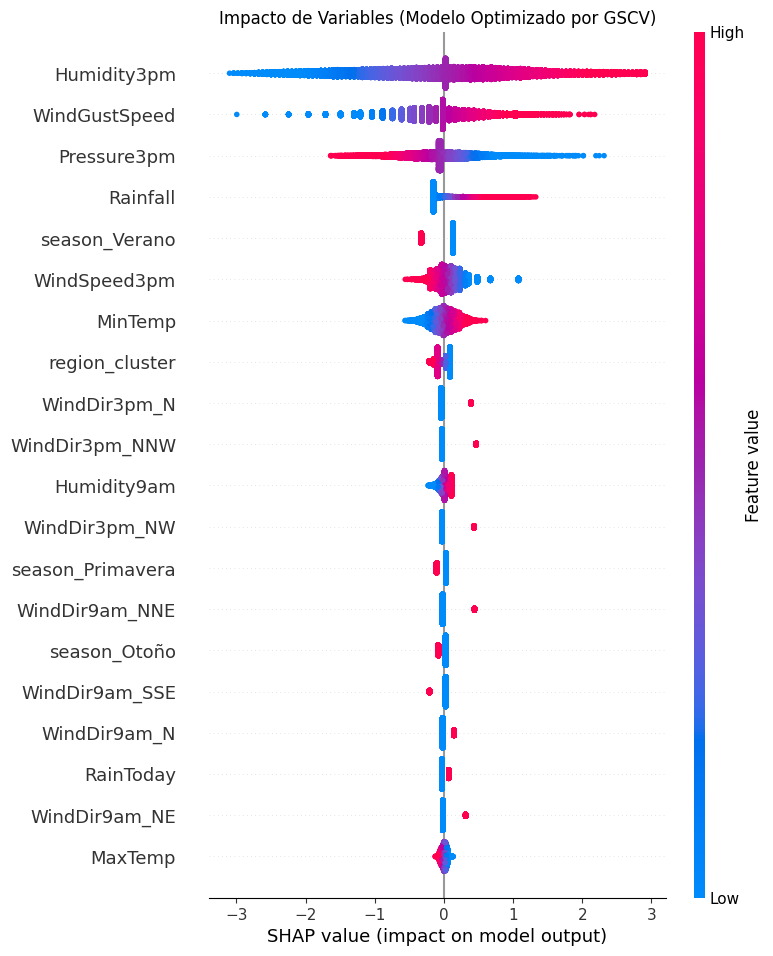

In [ ]:
plt.figure()
shap.summary_plot(
    shap_values_base.astype(float), 
    datos_a_explicar.astype(float), 
    plot_type="bar", 
    show=False
)
plt.title("Variables más importantes (Modelo Optimizado por GSCV)")

plt.figure()
shap.summary_plot(
    shap_values_base.astype(float), 
    datos_a_explicar.astype(float), 
    plot_type="dot", 
    show=False)
plt.title("Impacto de Variables (Modelo Optimizado por GSCV)")
plt.show()

Gráficos Locales.

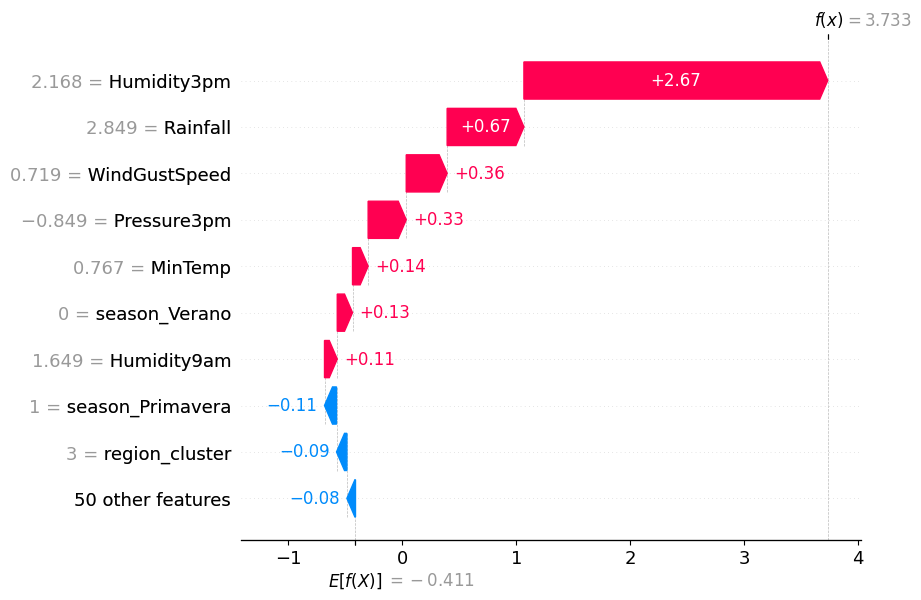

In [ ]:
i1, i2 = 0, 50
shap.initjs()

display(shap.force_plot(
    explainer_base.expected_value, 
    shap_values_base[i1,:].astype(float), 
    datos_a_explicar.iloc[i1,:].astype(float)))


exp_obj_local = shap.Explanation(
    values=shap_values_base[i2,:],
    base_values=explainer_base.expected_value,
    data=datos_a_explicar.iloc[i2,:].values,
    feature_names=datos_a_explicar.columns)

shap.waterfall_plot(exp_obj_local)
plt.show()
plt.show()

**Conclusiones sobre lo visto del Modelo Optimizado:**

El GridSearchCV (que te cambió el l1_ratio de 0.5 a 0.8) solo hizo un ajuste fino, pero la lógica fundamental del modelo sigue siendo la misma. Se obseva técnicamente lo mismo, con poco cambio, de lo anterior.

### AutoML

In [92]:
from pycaret.classification import setup, compare_models, pull, finalize_model, predict_model

Se trae de nuevo a los datos crudos (data) para haer AutoML. Se elimina lo necesario para seguir las patrones que tenía previo al split anterior.

In [93]:
data_cruda = data.copy()

In [94]:
data_cruda = data_cruda.dropna(subset=['RainTomorrow'])

X = data.drop(columns=['RainTomorrow', 'Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am'], axis=1)
Y = data['RainTomorrow']

In [95]:
data_cruda = data_cruda.drop(columns=['Pressure9am', 'Temp9am', 'Temp3pm'])
data_cruda['RainTomorrow'] = data_cruda['RainTomorrow'].map({'Yes': 1, 'No': 0})

X_automl = data_cruda.drop(columns=['RainTomorrow', 'Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am'], axis=1)
Y_automl = data_cruda['RainTomorrow']

In [96]:
train_df, test_df = train_test_split(data_cruda, test_size=0.2, random_state=42, stratify=Y_automl)

In [ ]:
clf_automl = setup(
    data=train_df,
    target='RainTomorrow',
    session_id=42,
    normalize=True,
    transformation=True,
    fix_imbalance=True,
    ignore_features=['Date'],
    verbose=False
)

In [ ]:
# Buscamos el mejor modelo ordenando por Recall F1 por el desbalanceado de categorías en la var. obj.
best_model_pycaret = compare_models(sort='f1', n_select=1)

results_df = pull()
print("\nResultados de los modelos de AutoML (Top 5, Ordenados por F1):")
print(results_df.head(5))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8528,0.8803,0.5804,0.7099,0.6386,0.5473,0.5517,18.5050
lightgbm,Light Gradient Boosting Machine,0.8541,0.8833,0.5593,0.7268,0.6321,0.5430,0.5503,8.3040
gbc,Gradient Boosting Classifier,0.8345,0.8649,0.6177,0.6348,0.6261,0.5199,0.5200,29.4290
et,Extra Trees Classifier,0.8472,0.8726,0.5434,0.7073,0.6146,0.5213,0.5284,16.4250
ada,Ada Boost Classifier,0.8130,0.8449,0.6361,0.5752,0.6040,0.4821,0.4832,11.6880
svm,SVM - Linear Kernel,0.8370,0.8528,0.5045,0.6858,0.5809,0.4827,0.4917,5.5220
nb,Naive Bayes,0.7535,0.7940,0.6438,0.4642,0.5394,0.3772,0.3866,5.9900
dt,Decision Tree Classifier,0.7769,0.6987,0.5572,0.5022,0.5283,0.3827,0.3836,7.1890
ridge,Ridge Classifier,0.8379,0.8641,0.4032,0.7614,0.5272,0.4403,0.4728,5.0100
lda,Linear Discriminant Analysis,0.8379,0.8641,0.4032,0.7614,0.5271,0.4402,0.4727,5.9680



Resultados de los modelos de AutoML (Top 5, Ordenados por F1):
                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.8528  0.8803  0.5804  0.7099   
lightgbm  Light Gradient Boosting Machine    0.8541  0.8833  0.5593  0.7268   
gbc          Gradient Boosting Classifier    0.8345  0.8649  0.6177  0.6348   
et                 Extra Trees Classifier    0.8472  0.8726  0.5434  0.7073   
ada                  Ada Boost Classifier    0.8130  0.8449  0.6361  0.5752   

              F1   Kappa     MCC  TT (Sec)  
rf        0.6386  0.5473  0.5517    18.505  
lightgbm  0.6321  0.5430  0.5503     8.304  
gbc       0.6261  0.5199  0.5200    29.429  
et        0.6146  0.5213  0.5284    16.425  
ada       0.6040  0.4821  0.4832    11.688  


In [ ]:
print("Modelo de AutoML Seleccionado:")
print(type(best_model_pycaret).__name__)

Modelo de AutoML Seleccionado:
RandomForestClassifier


**Interpretación:**

Cuando las clases están desbalanceadas, como es en este caso, es preferible usar F1-Score, debido a que su naturaleza como media armónica penaliza fuertemente si cualquiera de las métricas (Precisión o Recall) es muy baja. Un F1-Score alto indica que el mejor modelo (Random Forest Classifier) ha encontrado un mejor equilibrio entre detectar la lluvia real (alto Recall) y evitar falsas alarmas de lluvia (alta Precisión).
Asimismo, el hecho de que Random Forest (un modelo no lineal) haya superado a la Logistic Regression (un modelo lineal) sugiere que los patrones que predicen la lluvia son no lineales.